In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

In [2]:
manual_scores = pd.read_csv("/users/1/lundq163/projects/automated-qc/data/raw/auto_qc_t1w_t2w_subset_1024r_fixed.csv")
manual_scores.head()

,subject_id,session_id,run_id,suffix,scan,QU_motion,corrected_QU_motion
0,sub-100079,ses-V02,1,T2w,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247,ses-V02,1,T2w,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524,ses-V02,1,T2w,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586,ses-V02,1,T2w,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895,ses-V02,1,T2w,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [3]:
# drop the following columns: "subject_id", "session_id", "run_id", "suffix"
manual_scores = manual_scores.drop(columns=["subject_id", "session_id", "run_id", "suffix"])
manual_scores.head()

,scan,QU_motion,corrected_QU_motion
0,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [4]:
# rename the columns to be more descriptive
manual_scores = manual_scores.rename(columns={"QU_motion": "dons_scores", "corrected_QU_motion": "fj_updated_scores"})
manual_scores.head()

,scan,dons_scores,fj_updated_scores
0,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,3.0
1,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,3.0
2,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,1.0
3,sub-100586_ses-V02_run-1_T2w.nii.gz,0.0,0.5
4,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,1.0


In [5]:
model_scores = pd.read_csv("~/projects/automated-qc/doc/models/model_02r/model_02r5.csv")
model_scores.head()

,subject_id,session_id,run_id,suffix,scan,QU_motion,predicted_qu_motion_score
0,sub-100079,ses-V02,1,T2w,sub-100079_ses-V02_run-1_T2w.nii.gz,3.0,NaN
1,sub-100247,ses-V02,1,T2w,sub-100247_ses-V02_run-1_T2w.nii.gz,3.0,NaN
2,sub-100524,ses-V02,1,T2w,sub-100524_ses-V02_run-1_T2w.nii.gz,1.0,NaN
3,sub-100586,ses-V02,1,T2w,sub-100586_ses-V02_run-1_T2w.nii.gz,0.5,NaN
4,sub-100895,ses-V02,1,T2w,sub-100895_ses-V02_run-1_T2w.nii.gz,1.0,NaN


In [6]:
# drop the following columns: "subject_id", "session_id", "run_id", "suffix", "QU_motion"
model_scores = model_scores.drop(columns=["subject_id", "session_id", "run_id", "suffix", "QU_motion"])
model_scores.head()

,scan,predicted_qu_motion_score
0,sub-100079_ses-V02_run-1_T2w.nii.gz,NaN
1,sub-100247_ses-V02_run-1_T2w.nii.gz,NaN
2,sub-100524_ses-V02_run-1_T2w.nii.gz,NaN
3,sub-100586_ses-V02_run-1_T2w.nii.gz,NaN
4,sub-100895_ses-V02_run-1_T2w.nii.gz,NaN


In [7]:
# drop rows where predicted_qu_motion_score is NaN
model_scores = model_scores.dropna(subset=["predicted_qu_motion_score"])
model_scores.head()

,scan,predicted_qu_motion_score
12,sub-102673_ses-V02_run-1_T2w.nii.gz,0.762694
13,sub-102673_ses-V03_run-1_T2w.nii.gz,0.960739
24,sub-103199_ses-V02_run-1_T2w.nii.gz,0.674869
25,sub-103450_ses-V02_run-1_T2w.nii.gz,2.501921
26,sub-103450_ses-V02_run-2_T2w.nii.gz,2.443563


In [8]:
# merge the two dataframes on the scan column
merged_scores = pd.merge(manual_scores, model_scores, on="scan")
merged_scores.head()

,scan,dons_scores,fj_updated_scores,predicted_qu_motion_score
0,sub-102673_ses-V02_run-1_T2w.nii.gz,1.0,0.5,0.762694
1,sub-102673_ses-V03_run-1_T2w.nii.gz,0.0,0.5,0.960739
2,sub-103199_ses-V02_run-1_T2w.nii.gz,0.0,0.0,0.674869
3,sub-103450_ses-V02_run-1_T2w.nii.gz,1.0,2.0,2.501921
4,sub-103450_ses-V02_run-2_T2w.nii.gz,1.0,2.0,2.443563


In [9]:
merged_scores.shape

(213, 4)

In [10]:
thresholds = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

for threshold in thresholds:
    # create binary labels for dons_scores
    merged_scores[f"old_manual_label_{threshold}"] = merged_scores["dons_scores"] >= threshold
    
    # create binary labels for the manual scores using the threshold
    merged_scores[f"manual_label_{threshold}"] = merged_scores["fj_updated_scores"] >= 3
    
    # create binary labels for model scores
    merged_scores[f"model_label_{threshold}"] = merged_scores["predicted_qu_motion_score"] >= threshold
    
    # Create confusion matrix columns for dons_scores vs fj_updated_scores
    merged_scores[f"dons_tp_{threshold}"] = (merged_scores[f"old_manual_label_{threshold}"] == True) & (merged_scores[f"manual_label_{threshold}"] == True)
    merged_scores[f"dons_fp_{threshold}"] = (merged_scores[f"old_manual_label_{threshold}"] == True) & (merged_scores[f"manual_label_{threshold}"] == False)
    merged_scores[f"dons_tn_{threshold}"] = (merged_scores[f"old_manual_label_{threshold}"] == False) & (merged_scores[f"manual_label_{threshold}"] == False)
    merged_scores[f"dons_fn_{threshold}"] = (merged_scores[f"old_manual_label_{threshold}"] == False) & (merged_scores[f"manual_label_{threshold}"] == True)
    
    # Create confusion matrix columns for model_scores vs fj_updated_scores
    merged_scores[f"model_tp_{threshold}"] = (merged_scores[f"model_label_{threshold}"] == True) & (merged_scores[f"manual_label_{threshold}"] == True)
    merged_scores[f"model_fp_{threshold}"] = (merged_scores[f"model_label_{threshold}"] == True) & (merged_scores[f"manual_label_{threshold}"] == False)
    merged_scores[f"model_tn_{threshold}"] = (merged_scores[f"model_label_{threshold}"] == False) & (merged_scores[f"manual_label_{threshold}"] == False)
    merged_scores[f"model_fn_{threshold}"] = (merged_scores[f"model_label_{threshold}"] == False) & (merged_scores[f"manual_label_{threshold}"] == True)

In [11]:
merged_scores.head()

,scan,dons_scores,fj_updated_scores,predicted_qu_motion_score,old_manual_label_0.0,manual_label_0.0,model_label_0.0,dons_tp_0.0,dons_fp_0.0,dons_tn_0.0,dons_fn_0.0,model_tp_0.0,model_fp_0.0,model_tn_0.0,model_fn_0.0,old_manual_label_0.5,manual_label_0.5,model_label_0.5,dons_tp_0.5,dons_fp_0.5,dons_tn_0.5,dons_fn_0.5,model_tp_0.5,model_fp_0.5,model_tn_0.5,model_fn_0.5,old_manual_label_1.0,manual_label_1.0,model_label_1.0,dons_tp_1.0,dons_fp_1.0,dons_tn_1.0,dons_fn_1.0,model_tp_1.0,model_fp_1.0,model_tn_1.0,model_fn_1.0,old_manual_label_1.5,manual_label_1.5,model_label_1.5,dons_tp_1.5,dons_fp_1.5,dons_tn_1.5,dons_fn_1.5,model_tp_1.5,model_fp_1.5,model_tn_1.5,model_fn_1.5,old_manual_label_2.0,manual_label_2.0,model_label_2.0,dons_tp_2.0,dons_fp_2.0,dons_tn_2.0,dons_fn_2.0,model_tp_2.0,model_fp_2.0,model_tn_2.0,model_fn_2.0,old_manual_label_2.5,manual_label_2.5,model_label_2.5,dons_tp_2.5,dons_fp_2.5,dons_tn_2.5,dons_fn_2.5,model_tp_2.5,model_fp_2.5,model_tn_2.5,model_fn_2.5,old_manual_label_3.0,manual_label_3.0,model_label_3.0,dons_tp_3.0,dons_fp_3.0,dons_tn_3.0,dons_fn_3.0,model_tp_3.0,model_fp_3.0,model_tn_3.0,model_fn_3.0
0,sub-102673_ses-V02_run-1_T2w.nii.gz,1.0,0.5,0.762694,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False
1,sub-102673_ses-V03_run-1_T2w.nii.gz,0.0,0.5,0.960739,True,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False
2,sub-103199_ses-V02_run-1_T2w.nii.gz,0.0,0.0,0.674869,True,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False
3,sub-103450_ses-V02_run-1_T2w.nii.gz,1.0,2.0,2.501921,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False
4,sub-103450_ses-V02_run-2_T2w.nii.gz,1.0,2.0,2.443563,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,True,False,True,False,True,False,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False


In [12]:
markdown_content = "# Comparison of Model Predictions and Old Manual Labels to New Manual Labels\n\n"
markdown_content += "| y_pred | Threshold | Totals| TP | FP | TN | FN | Accuracy | PPV | NPV |\n"
markdown_content += "| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n"


tpr_don = []
fpr_don = []
tpr_model = []
fpr_model = []


for threshold in thresholds:
        tp_don = np.sum(merged_scores[f"dons_tp_{threshold}"])
        fp_don = np.sum(merged_scores[f"dons_fp_{threshold}"])
        tn_don = np.sum(merged_scores[f"dons_tn_{threshold}"])
        fn_don = np.sum(merged_scores[f"dons_fn_{threshold}"])
        accuracy_don = (tp_don + tn_don) / (tp_don + fp_don + tn_don + fn_don) if (tp_don + fp_don + tn_don + fn_don) > 0 else 0
        ppv_don = tp_don / (tp_don + fp_don) if (tp_don + fp_don) > 0 else 0
        npv_don = tn_don / (tn_don + fn_don) if (tn_don + fn_don) > 0 else 0
        tpr_don.append(tp_don / (tp_don + fn_don))
        fpr_don.append(fp_don / (tn_don + fp_don))
        
        
        tp_model = np.sum(merged_scores[f"model_tp_{threshold}"])
        fp_model = np.sum(merged_scores[f"model_fp_{threshold}"])
        tn_model = np.sum(merged_scores[f"model_tn_{threshold}"])
        fn_model = np.sum(merged_scores[f"model_fn_{threshold}"])
        accuracy_model = (tp_model + tn_model) / (tp_model + fp_model + tn_model + fn_model) if (tp_model + fp_model + tn_model + fn_model) > 0 else 0
        ppv_model = tp_model / (tp_model + fp_model) if (tp_model + fp_model) > 0 else 0
        npv_model = tn_model / (tn_model + fn_model) if (tn_model + fn_model) > 0 else 0
        tpr_model.append(tp_model / (tp_model + fn_model))
        fpr_model.append(fp_model / (fp_model + tn_model))

        markdown_content += f"| old_manual_{threshold} | {threshold} | {tp_don + fp_don + tn_don + fn_don} | {tp_don} | {fp_don} | {tn_don} | {fn_don} | {accuracy_don:.4f} | {ppv_don:.4f} | {npv_don:.4f} |\n"
        markdown_content += f"| model_{threshold} | {threshold} | {tp_model + fp_model + tn_model + fn_model} | {tp_model} | {fp_model} | {tn_model} | {fn_model} | {accuracy_model:.4f} | {ppv_model:.4f} | {npv_model:.4f} |\n"

In [13]:
tpr_don

[np.float64(1.0),
 np.float64(0.9743589743589743),
 np.float64(0.9743589743589743),
 np.float64(0.9743589743589743),
 np.float64(0.9230769230769231),
 np.float64(0.7948717948717948),
 np.float64(0.7435897435897436)]

In [14]:
fpr_don

[np.float64(1.0),
 np.float64(0.6379310344827587),
 np.float64(0.5459770114942529),
 np.float64(0.14942528735632185),
 np.float64(0.05747126436781609),
 np.float64(0.034482758620689655),
 np.float64(0.034482758620689655)]

In [15]:
tpr_model

[np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.8717948717948718),
 np.float64(0.5897435897435898),
 np.float64(0.1794871794871795)]

In [16]:
fpr_model

[np.float64(0.9942528735632183),
 np.float64(0.9482758620689655),
 np.float64(0.6149425287356322),
 np.float64(0.3620689655172414),
 np.float64(0.15517241379310345),
 np.float64(0.022988505747126436),
 np.float64(0.005747126436781609)]

In [17]:
import matplotlib.pyplot as plt

In [18]:
auc_don = np.trapezoid(tpr_don, fpr_don)
auc_don * -1

np.float64(0.9403919834954316)

/tmp/ipykernel_3077216/1599083605.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'lower right')


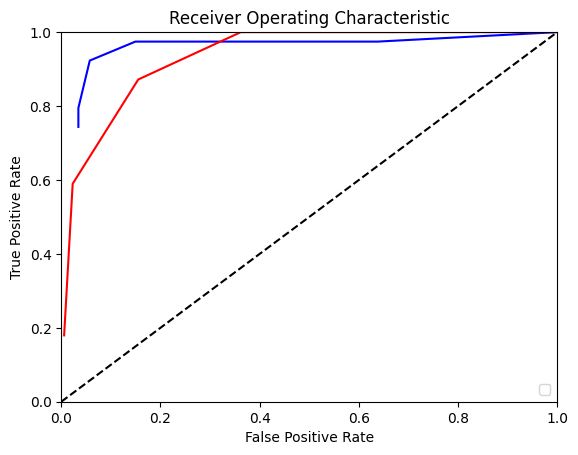

In [19]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_don, tpr_don, 'b')
plt.plot(fpr_model, tpr_model, 'r')
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'k--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

/tmp/ipykernel_2656216/2590793448.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 'lower right')


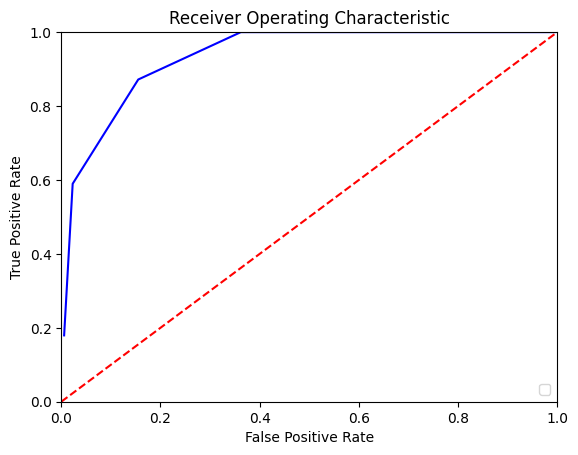

In [110]:
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_model, tpr_model, 'b')
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [59]:
#merged_scores_old_manual_v_new_manual = merged_scores[[f"old_manual_label_{threshold}" for threshold in thresholds] + [f"manual_label_{threshold}" for threshold in thresholds]]
#merged_scores_old_manual_v_new_manual.head()

In [60]:
#merged_scores_model_v_new_manual = merged_scores[[f"model_label_{threshold}" for threshold in thresholds] + [f"manual_label_{threshold}" for threshold in thresholds]]
#merged_scores_model_v_new_manual.head()

In [61]:
#analysis_dfs = [merged_scores_old_manual_v_new_manual, merged_scores_model_v_new_manual]
#analysis_dfs

In [62]:
# markdown_content = "# Comparison of Model Predictions and Old Manual Labels to New Manual Labels\n\n"
# markdown_content += "| y_pred | Threshold | Totals| TP | FP | TN | FN | Accuracy | PPV | NPV |\n"
# markdown_content += "| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n"

# for df in analysis_dfs:
#     print(df.head())
#     print(df.columns)
    
#     metrics = []

#     for threshold in thresholds:
#         prediction_column = f"model_label_{threshold}" if "model_label" in df.columns[0] else f"old_manual_label_{threshold}"
#         print(f"Analyzing {prediction_column} compared to new manual labels...")
        
#         predicted = df[prediction_column]
#         print(f"Predicted labels for threshold {threshold}:\n{predicted.head()}")
#         actual = df[f"manual_label_{threshold}"]
#         print(f"Actual labels for threshold {threshold}:\n{actual.head()}")
#         tp = np.sum((predicted == True) & (actual == True))
#         fp = np.sum((predicted == True) & (actual == False))
#         tn = np.sum((predicted == False) & (actual == False))
#         fn = np.sum((predicted == False) & (actual == True))

#         accuracy = (tp + tn) / (tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0
#         ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
#         npv = tn / (tn + fn) if (tn + fn) > 0 else 0

#         markdown_content += f"| {prediction_column} | {threshold} | {tp + fp + tn + fn} | {tp} | {fp} | {tn} | {fn} | {accuracy:.4f} | {ppv:.4f} | {npv:.4f} |\n"
        
#         metrics.append({
#             'y_pred': prediction_column,
#             'threshold': threshold,
#             'accuracy': accuracy,
#             'ppv': ppv,
#             'npv': npv
#         })

In [77]:
output_md = f"comparison_to_new_manual_labels.md"

with open(output_md, 'w') as f:
    f.write(markdown_content)

In [51]:
# # create a table of accuracy, ppv, and npv comparing dons_scores and predicted_qu_motion_score to fj_updated_scores at each score threshold: 0.5, 1.0, 1.5, 2.0, 2.5, 3.0

# thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
# results = []
# for threshold in thresholds:
#     # create binary labels for the manual scores using the threshold
#     merged_scores["manual_label"] = merged_scores["fj_updated_scores"] >= threshold
#     print(merged_scores[["fj_updated_scores", "manual_label"]].head())
#     # create binary labels for the model scores using the threshold
#     merged_scores["model_label"] = merged_scores["predicted_qu_motion_score"] >= threshold
#     print(merged_scores[["predicted_qu_motion_score", "model_label"]].head())
#     # calculate accuracy, ppv, and npv for the model scores compared to the manual scores
#     accuracy = accuracy_score(merged_scores["manual_label"], merged_scores["model_label"])
#     ppv = precision_score(merged_scores["manual_label"], merged_scores["model_label"])
#     npv = precision_score(merged_scores["manual_label"], merged_scores["model_label"], pos_label=0)
#     results.append({"threshold": threshold, "accuracy": accuracy, "ppv": ppv, "npv": npv})
# results_df = pd.DataFrame(results)
# results_df

